In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from langchain_community.tools import DuckDuckGoSearchRun
from dotenv import load_dotenv

load_dotenv()

C:\Users\dell\AppData\Local\Temp\ipykernel_34352\407901463.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, TextLoader


True

In [2]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

llm = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')
embedding = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')    

In [3]:
# 1. just load the doc

docs = (
    TextLoader("../Document/hr.txt").load()
)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(docs)

vector_store = FAISS.from_documents(chunks, embedding=embedding)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [53]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------

class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str

    web_query: str
    total_web_search:int

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: str

    # to revice revise the answer if ans is not fully supported from the doc
    retries: int

    # usefulness check
    isuse: Literal["useful", "not_useful"]
    reason: str

    # if not usefull the rewrite the question
    retrieval_query: str
    rewrite_tries: int
    
    answer: str
    

In [27]:
# --------------------------------------------------
# find that retrival is needed or not
# --------------------------------------------------

class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


def decide_retrieval(state: State):
    question = state['question']

    res = (decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision) ).invoke({'question': question}).should_retrieve
    
    return {
        'need_retrieval': res
    }

In [28]:
# -----------------------------
# 1) Decide retrieval
# -----------------------------

direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "I don't know based on my general knowledge.\n"
            "if question say that use the use the context or use knowledgebase then you do not give the answer by your self"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content[0]['text']
    }

In [29]:
# -----------------------------
# 3) Retrieve
# -----------------------------

def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [30]:
# -----------------------------
# 4) Relevance filter 
# -----------------------------

class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)


def is_relevant(state:State):

    relevant_docs : List[Document] = []
    
    chain = (is_relevant_prompt | llm.with_structured_output(RelevanceDecision))
    
    for d in state['docs']:
        res = chain.invoke({'question':state['question'], 'document':d}).is_relevant

        if res :
            relevant_docs.append(d)

    return {
        'relevant_docs':relevant_docs
    }

In [31]:
def route_after_decide(state:State):

    if state['need_retrieval']:
        return "retrieve"
    else:
        return "generate_direct"

In [32]:
# -----------------------------
# 5) Generate from context
# ----------------------------

rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state:State):

    context = "".join([d.page_content for d in state['relevant_docs']]).strip()

    out = (rag_generation_prompt | llm ).invoke({'question': state['question'], "context":context})

    return {
        'answer': out.content[0]['text'], 
        'context':context
    }

In [33]:
# -----------------------------
# web search & query rewrite
# -----------------------------
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


def rewrite_query_node(state:State)->str:
    query = state["question"]

    rewrite_query = rewrite_chain.invoke({"question":query}).query

    return {
        'web_query':rewrite_query
    }

def web_search(state:State):
    search = DuckDuckGoSearchRun()

    q = state["web_query"]
    total_web_search = state['total_web_search']
    # Run a query directly
    results = search.run(q)

    return {
        "docs":[Document(page_content=results)],
        "total_web_search": total_web_search - 1
    }

In [34]:
def route_after_relevance(state:State):
    if len(state['relevant_docs']) > 0 or state['total_web_search'] == 0:
        return "generate_from_context"
    else :
        return "rewrite_query_node"

In [35]:
# -----------------------------
# 6) IsSUP verify 
# -----------------------------

class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: str

prompt = '''
"system",
"""Verify whether the ANSWER is supported by the CONTEXT.

issup:
- fully_supported: All meaningful claims are explicitly supported by CONTEXT.
- partially_supported: Core facts are supported, but there is any unsupported interpretation or qualitative wording.
- no_support: Key claims are unsupported or mostly unrelated.

Be strict. Do not use outside knowledge.
Evidence: provide up to 1 short direct quotes from CONTEXT."""
'''

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            prompt
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ])


def ans_is_supported(state:State):
    res = (issup_prompt | llm.with_structured_output(IsSUPDecision)).invoke({"question":state['question'], "answer":state['answer'], 
        "context":state['context']})

    return {
        "issup":res.issup,
        'evidence':res.evidence
    }

In [36]:
# -----------------------------
# 7) revise loop
# -----------------------------

revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)


def revise_answer(state:State):
    output = llm.invoke({"question":state['question'], "answer":state['answer'], "context":state['context']}).content[0]['text']

    print("revise call")

    return {
        "retries":state['retries']-1,
        'answer': output
    }

In [37]:
# -----------------------------
# 8) accept answer
# -----------------------------
def accept_answer(state: State):
    return {}  # keep answer as-is

In [38]:
# check the answer

def route_after_issup(state:State):
    if state['issup'] == 'fully_supported' or state['retries'] == 0:
        return "accept_answer"
    else:
        return "revise_answer"
    

In [47]:
# -----------------------------
# 9) check that ans is usefull or not
# -----------------------------

class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\n answer:\n{answer}"
        ),
    ]
)

def ans_is_usefull(state:State):
    output = (isuse_prompt | llm.with_structured_output(IsUSEDecision)).invoke({'question':state['question'], "answer":state['answer']})

    return {
        'reason':output.reason,
        'isuse':output.isuse
    }

In [54]:
# -----------------------------
# 10) check that ans is usefull or not
# -----------------------------

class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)

def rewrite_question(state:State):
    output = (rewrite_for_retrieval_prompt | llm.with_structured_output(RewriteDecision)).invoke({'question':state['question'], "answer":state['answer'], "retrieval_query":state['retrieval_query']})

    return {
        'retrieval_query':output.retrieval_query,
        "rewrite_tries":state['rewrite_tries']-1,

        # reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

In [ ]:
# chek the anser's usefullness
def route_after_isuse(state:State):
    if state['isuse'] == 'useful':
        return "END"
    elif state['rewrite_tries'] == 0:
        return "rewrite_query_node"
    else:
        return "rewrite_question"

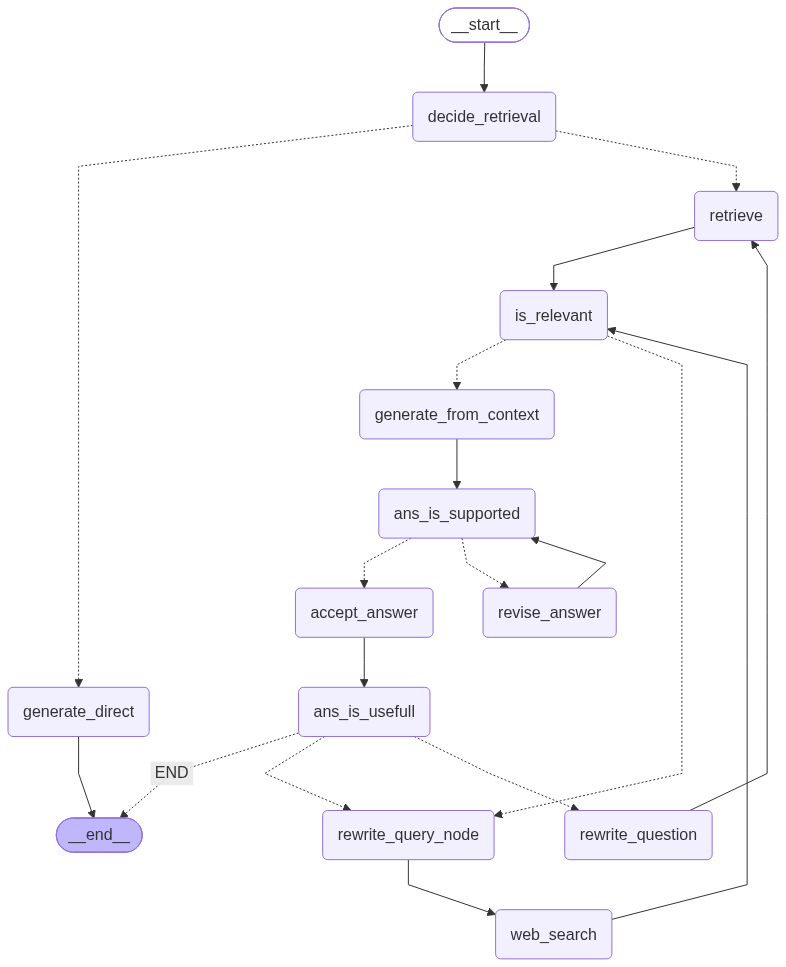

In [56]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant) 
g.add_node("generate_from_context", generate_from_context)
g.add_node("ans_is_supported", ans_is_supported)
g.add_node("revise_answer", revise_answer)
g.add_node("accept_answer",accept_answer)
g.add_node("ans_is_usefull", ans_is_usefull)
g.add_node("rewrite_question", rewrite_question)

g.add_node("rewrite_query_node", rewrite_query_node)
g.add_node("web_search", web_search)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

# --------------------
# check the retrival is needed or not
# --------------------
g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)
g.add_edge("generate_direct", END)
g.add_edge("retrieve", "is_relevant") 

# --------------------
# check that retrive dos is relavent or not
# --------------------

g.add_conditional_edges("is_relevant", route_after_relevance, {
    "generate_from_context":"generate_from_context",
    "rewrite_query_node":"rewrite_query_node"
}) 

# --------------------
#  if retrive doc is not relavent then web search and loop to relavence check
# --------------------
g.add_edge("rewrite_query_node", "web_search")
g.add_edge("web_search", "is_relevant")

# --------------------
# if doc is relavent then generate the answer
# --------------------
g.add_edge('generate_from_context', 'ans_is_supported')

# --------------------
# check the answer is generated from the context only
# --------------------
g.add_conditional_edges('ans_is_supported', route_after_issup, {
    "accept_answer":"accept_answer",
    "revise_answer":"revise_answer"
})

# --------------------
# if not supported then regenerate the ans 
# --------------------
g.add_edge('revise_answer', 'ans_is_supported')

# --------------------
# check that answer is usefull to give the ans of the user que
# --------------------
g.add_edge("accept_answer", "ans_is_usefull")

# --------------------
# if usefull then end if not the websearch
# --------------------
g.add_conditional_edges("ans_is_usefull", route_after_isuse,{
    "END":END,
    "rewrite_question":"rewrite_question",
    "rewrite_query_node":"rewrite_query_node"
})


# --------------------
# if not usefull
# --------------------
g.add_edge('rewrite_question', "retrieve")

# --------------------
# end
# --------------------
g.add_edge("accept_answer", END)
app = g.compile()
app

In [57]:
result = app.invoke(
    {
        "question": "how many WFH i have if i use 8 and what is cto",
        "need_retrieval": False,
        "docs": [],
        "web_query":"",
        "answer": "",
        'total_web_search':1,

        "issup": "",
        "evidence": "",

        "retries": 1,

        "retrieval_query":"",
        "rewrite_tries": 1
    }
)


In [58]:
result

{'question': 'how many WFH i have if i use 8 and what is cto',
 'need_retrieval': True,
 'docs': [Document(id='0e3b2002-5d9b-424d-8ca4-1afcfc52a3cd', metadata={'source': '../Document/hr.txt'}, page_content='## 2. Leave Policy\n\nEmployees receive:\n\n* Casual Leave: **8 days/year**\n* Sick Leave: **8 days/year**\n* Earned Leave: **15 days/year**\n\nEarned leave should normally be requested at least **7 days in advance**.\n\n## 3. Work From Home\n\nEligible employees can request up to **8 WFH days per month** with manager approval.\n\n## 4. Probation\n\nNew employees have a standard **6-month probation period**.'),
  Document(id='8e1c15c3-d97c-47cf-9fa1-7299af0d50c0', metadata={'source': '../Document/hr.txt'}, page_content='## 7. Workplace Conduct\n\nEmployees must maintain professional behavior. Harassment, discrimination, bullying, and unauthorized disclosure of confidential information are prohibited.\n\n## 8. Confidentiality\n\nEmployees must protect company information, including c